In [7]:
"""
Notebook de Resultados - Práctica 3
===================================
Este notebook carga, agrega y visualiza los resultados de los modelos entrenados
(KNN, SVM, Naive Bayes, Random Forest) y sus combinaciones mediante ensembles
(Votación, Media, Mediana) sobre diferentes versiones del dataset.

Genera tablas resumen y gráficas comparativas para el análisis del rendimiento.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score
import warnings

# Ignoramos warnings de división por cero (común en validación cruzada si una clase no aparece)
warnings.filterwarnings('ignore')

## Configuración

En esta sección definimos las constantes principales del análisis:
- **METHODS**: Lista de algoritmos evaluados (modelos base + ensembles)
- **DATASETS**: Variantes del conjunto de datos (original, normalizado, estandarizado, con y sin PCA)
- **METRICS**: Métricas de evaluación calculadas para cada modelo
- **Rutas**: Ubicación de los archivos de predicciones y métricas generados por `eval.ipynb`

In [8]:
# Algoritmos individuales y Ensembles
METHODS = [
    "KNN", "SVM", "NaiveBayes", "RandomForest", 
    "Ensemble_Votacion", "Ensemble_Media", "Ensemble_Mediana"
]

# Versiones del conjunto de datos utilizadas
DATASETS = [
    "original", "estandarizado", "normalizado",
    "original_PCA95", "original_PCA80",
    "estandarizado_PCA95", "estandarizado_PCA80",
    "normalizado_PCA95", "normalizado_PCA80"
]

# Métricas solicitadas en el enunciado
METRICS = [
    "F1", "Sensibilidad", "Exactitud", "Especificidad", 
    "Recall", "Precision", "FNR", "FPR", "AUC"
]

FOLDS = 5  # Número de pliegues en validación cruzada

# Rutas de archivos
PATH_PREDICCIONES = "./predicciones"
PATH_METRICAS = "./metricas"

## Carga y Agregación de Datos

Esta sección contiene las funciones para:
1. **Calcular métricas personalizadas**: A partir de las predicciones y probabilidades, calcula F1, Sensibilidad, Exactitud, Especificidad, Recall, Precision, FNR, FPR y AUC.
2. **Cargar y agregar resultados**: Lee los archivos de métricas generados por `eval.ipynb` para cada método, dataset y fold, calculando la media y desviación estándar de cada métrica.

In [9]:
def calculate_custom_metrics(y_true, y_pred, y_proba):
    """
    Calcula las métricas solicitadas a partir de predicciones.
    Adapta fórmulas binarias a multiclase usando macro-average.
    """
    # Métricas básicas de sklearn (usando 'macro' para multiclase)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro')
    
    # Métricas derivadas de la Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    
    # Cálculo de TP, TN, FP, FN por clase
    FP = cm.sum(axis=0) - np.diag(cm)  
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    # Evitar división por cero
    epsilon = 1e-7 
    
    # Promedios macro de las tasas
    spec_macro = np.mean(TN / (FP + TN + epsilon))  # Especificidad
    fnr_macro = np.mean(FN / (TP + FN + epsilon))   # Tasa de Falsos Negativos
    fpr_macro = np.mean(FP / (FP + TN + epsilon))   # Tasa de Falsos Positivos
    
    # AUC (Area Under Curve)
    auc_val = 0
    if y_proba is not None:
        try:
            auc_val = roc_auc_score(y_true, y_proba, multi_class='ovr')
        except:
            pass

    return {
        "Exactitud": acc, 
        "F1": f1, 
        "Sensibilidad": rec, 
        "Recall": rec,
        "Precision": prec, 
        "Especificidad": spec_macro,
        "FNR": fnr_macro, 
        "FPR": fpr_macro, 
        "AUC": auc_val
    }


def load_and_aggregate_results():
    """
    Carga los resultados de métricas desde los archivos CSV generados por eval.ipynb.
    Agrega las métricas de los 5 folds calculando media y desviación estándar.
    """
    aggregated_data = []
    print("Iniciando carga y cálculo de métricas...")
    print("-" * 50)

    for method in METHODS:
        for dataset in DATASETS:
            fold_metrics = {m: [] for m in METRICS}
            
            # Iterar por los 5 folds
            for k in range(1, FOLDS + 1):
                # Ruta coherente con eval.ipynb: metricas/{METODO}/{dataset}/{METODO}{fold}_{dataset}_metrics.csv
                filename = f"{PATH_METRICAS}/{method}/{dataset}/{method}{k}_{dataset}_metrics.csv"
                
                try:
                    df = pd.read_csv(filename)
                    
                    # Extraer métricas del archivo
                    for m in METRICS:
                        if m in df.columns:
                            fold_metrics[m].append(df[m].values[0])
                        
                except FileNotFoundError:
                    # Si no existe el archivo, intentamos cargar desde predicciones
                    pred_filename = f"{PATH_PREDICCIONES}/{method}/{dataset}/{method}{k}_{dataset}_predicts.csv"
                    try:
                        df_pred = pd.read_csv(pred_filename)
                        y_true = df_pred['y_true'].values
                        y_pred = df_pred['y_pred'].values
                        
                        proba_cols = [c for c in df_pred.columns if 'prob_' in c]
                        y_proba = df_pred[proba_cols].values if proba_cols else None
                        
                        metrics_dict = calculate_custom_metrics(y_true, y_pred, y_proba)
                        
                        for m in METRICS:
                            fold_metrics[m].append(metrics_dict[m])
                            
                    except FileNotFoundError:
                        pass

            # Solo agregamos si encontramos datos
            if len(fold_metrics["F1"]) > 0:
                row = {'Method': method, 'Dataset': dataset}
                for m in METRICS:
                    values = fold_metrics[m] if fold_metrics[m] else [0]
                    
                    mean_val = np.mean(values)
                    std_val = np.std(values)
                    
                    row[f"{m}_mean"] = mean_val
                    row[f"{m}_std"] = std_val
                    
                    # Formato LaTeX para Tablas
                    row[f"{m}_display"] = f"{mean_val:.4f} $\\pm$ {std_val:.4f}"
                
                aggregated_data.append(row)
                print(f"Cargado: {method} - {dataset} ({len(fold_metrics['F1'])} folds)")

    print("-" * 50)
    print(f"Carga completada. Total de combinaciones: {len(aggregated_data)}")
    return pd.DataFrame(aggregated_data) # Devolvemos el DataFrame con los resultados agregados


# Ejecutar carga de datos
df_results = load_and_aggregate_results()
print("\nVista previa de los resultados:")
df_results.head()

Iniciando carga y cálculo de métricas...
--------------------------------------------------
Cargado: KNN - original (5 folds)
Cargado: KNN - estandarizado (5 folds)
Cargado: KNN - normalizado (5 folds)
Cargado: KNN - original_PCA95 (5 folds)
Cargado: KNN - original_PCA80 (5 folds)
Cargado: KNN - estandarizado_PCA95 (5 folds)
Cargado: KNN - estandarizado_PCA80 (5 folds)
Cargado: KNN - normalizado_PCA95 (5 folds)
Cargado: KNN - normalizado_PCA80 (5 folds)
Cargado: SVM - original (5 folds)
Cargado: SVM - estandarizado (5 folds)
Cargado: SVM - normalizado (5 folds)
Cargado: SVM - original_PCA95 (5 folds)
Cargado: SVM - original_PCA80 (5 folds)
Cargado: SVM - estandarizado_PCA95 (5 folds)
Cargado: SVM - estandarizado_PCA80 (5 folds)
Cargado: SVM - normalizado_PCA95 (5 folds)
Cargado: SVM - normalizado_PCA80 (5 folds)
Cargado: NaiveBayes - original (5 folds)
Cargado: NaiveBayes - estandarizado (5 folds)
Cargado: NaiveBayes - normalizado (5 folds)
Cargado: NaiveBayes - original_PCA95 (5 folds

,Method,Dataset,F1_mean,F1_std,F1_display,Sensibilidad_mean,Sensibilidad_std,Sensibilidad_display,Exactitud_mean,Exactitud_std,...,Precision_display,FNR_mean,FNR_std,FNR_display,FPR_mean,FPR_std,FPR_display,AUC_mean,AUC_std,AUC_display
0,KNN,original,1.000000,0.000000,1.0000 $\pm$ 0.0000,1.000000,0.000000,1.0000 $\pm$ 0.0000,1.000000,0.000000,...,1.0000 $\pm$ 0.0000,0.000000,0.000000,0.0000 $\pm$ 0.0000,0.000000,0.000000,0.0000 $\pm$ 0.0000,1.000000,0.000000,1.0000 $\pm$ 0.0000
1,KNN,estandarizado,0.959832,0.025080,0.9598 $\pm$ 0.0251,0.960000,0.024944,0.9600 $\pm$ 0.0249,0.960000,0.024944,...,0.9634 $\pm$ 0.0232,0.040000,0.024944,0.0400 $\pm$ 0.0249,0.020000,0.012472,0.0200 $\pm$ 0.0125,0.995000,0.004346,0.9950 $\pm$ 0.0043
2,KNN,normalizado,0.959900,0.032742,0.9599 $\pm$ 0.0327,0.960000,0.032660,0.9600 $\pm$ 0.0327,0.960000,0.032660,...,0.9623 $\pm$ 0.0322,0.040000,0.032660,0.0400 $\pm$ 0.0327,0.020000,0.016330,0.0200 $\pm$ 0.0163,0.997333,0.005333,0.9973 $\pm$ 0.0053
3,KNN,original_PCA95,0.966515,0.029966,0.9665 $\pm$ 0.0300,0.966667,0.029814,0.9667 $\pm$ 0.0298,0.966667,0.029814,...,0.9695 $\pm$ 0.0276,0.033333,0.029814,0.0333 $\pm$ 0.0298,0.016667,0.014907,0.0167 $\pm$ 0.0149,0.990667,0.010677,0.9907 $\pm$ 0.0107
4,KNN,original_PCA80,0.919765,0.045221,0.9198 $\pm$ 0.0452,0.920000,0.045216,0.9200 $\pm$ 0.0452,0.920000,0.045216,...,0.9232 $\pm$ 0.0456,0.080000,0.045216,0.0800 $\pm$ 0.0452,0.040000,0.022608,0.0400 $\pm$ 0.0226,0.977667,0.021281,0.9777 $\pm$ 0.0213


## Generación de Tablas para LaTeX

Esta sección genera tablas formateadas para incluir directamente en documentos LaTeX:

1. **Tablas por método**: Para cada algoritmo (KNN, SVM, etc.), genera una tabla donde las filas son los datasets y las columnas son las métricas. Muestra media ± desviación estándar.

2. **Tabla resumen F1-Score**: Tabla comparativa global donde las filas son los métodos y las columnas son los datasets, mostrando únicamente el F1-Score para facilitar la comparación rápida entre algoritmos.

In [10]:
def generate_method_tables(df):
    """
    Genera una tabla resumen para CADA método.
    
    Estructura de la tabla:
    - Filas: Datasets (original, normalizado, estandarizado, con/sin PCA)
    - Columnas: Métricas (F1, Sensibilidad, Exactitud, etc.)
    - Valores: media ± desviación estándar

    """
    for method in METHODS:
        print(f"\n{'='*60}")
        print(f"TABLA RESUMEN: {method}")
        print(f"{'='*60}")
        
        subset = df[df['Method'] == method].copy()
        
        if subset.empty:
            print(f"No hay datos para {method}")
            continue
        
        # Seleccionar solo las columnas de display 
        cols_display = [f"{m}_display" for m in METRICS]
        available_cols = [c for c in cols_display if c in subset.columns]
        table_display = subset.set_index('Dataset')[available_cols]
        
        # Renombrar columnas para quitar "_display"
        table_display.columns = [c.replace('_display', '') for c in table_display.columns]
        
        print(table_display.to_string())
        
        # Para exportar a LaTeX directamente (descome ntar):
        print("\nCódigo LaTeX:")
        print(table_display.to_latex(escape=False))


def generate_f1_summary_table(df):
    """
    Genera tabla comparativa de F1-Score entre todos los métodos y datasets.
    
    Estructura de la tabla:
    - Filas: Métodos (KNN, SVM, NaiveBayes, RandomForest, Ensembles)
    - Columnas: Datasets
    - Valores: F1-Score (media ± std)
    
    Esta tabla facilita comparar rápidamente qué algoritmo funciona mejor
    en cada versión del dataset.
    """
    print(f"\n{'='*60}")
    print("TABLA COMPARATIVA GLOBAL: F1-Score")
    print(f"{'='*60}")
    
    if 'F1_display' not in df.columns:
        print("No se encontró la columna F1_display")
        return
    
    # Pivotar la tabla
    pivot_f1 = df.pivot(index='Method', columns='Dataset', values='F1_display')
    
    # Reordenar columnas si es necesario
    ordered_cols = [d for d in DATASETS if d in pivot_f1.columns]
    pivot_f1 = pivot_f1[ordered_cols]
    
    print(pivot_f1.to_string())
    
    # Para exportar a LaTeX directamente (descomentar):
    # print("\nCódigo LaTeX:")
    # print(pivot_f1.to_latex(escape=False))


def generate_best_results_summary(df):
    """
    Genera un resumen de los mejores resultados por métrica.
    
    Para cada métrica, muestra el método y dataset que obtuvieron
    el mejor rendimiento.
    """
    print(f"\n{'='*60}")
    print("RESUMEN: MEJORES RESULTADOS POR MÉTRICA")
    print(f"{'='*60}")
    
    for metric in METRICS:
        col_mean = f"{metric}_mean"
        if col_mean in df.columns:
            # Para FNR y FPR, menor es mejor
            if metric in ['FNR', 'FPR']:
                best_idx = df[col_mean].idxmin()
            else:
                best_idx = df[col_mean].idxmax()
            
            best_row = df.loc[best_idx]
            print(f"\n{metric}:")
            print(f"  Mejor: {best_row['Method']} en {best_row['Dataset']}")
            print(f"  Valor: {best_row[f'{metric}_display']}")


# Ejecutar generación de tablas
generate_method_tables(df_results)
generate_f1_summary_table(df_results)
generate_best_results_summary(df_results)


TABLA RESUMEN: KNN
                                      F1         Sensibilidad            Exactitud        Especificidad               Recall            Precision                  FNR                  FPR                  AUC
Dataset                                                                                                                                                                                                         
original             1.0000 $\pm$ 0.0000  1.0000 $\pm$ 0.0000  1.0000 $\pm$ 0.0000  1.0000 $\pm$ 0.0000  1.0000 $\pm$ 0.0000  1.0000 $\pm$ 0.0000  0.0000 $\pm$ 0.0000  0.0000 $\pm$ 0.0000  1.0000 $\pm$ 0.0000
estandarizado        0.9598 $\pm$ 0.0251  0.9600 $\pm$ 0.0249  0.9600 $\pm$ 0.0249  0.9800 $\pm$ 0.0125  0.9600 $\pm$ 0.0249  0.9634 $\pm$ 0.0232  0.0400 $\pm$ 0.0249  0.0200 $\pm$ 0.0125  0.9950 $\pm$ 0.0043
normalizado          0.9599 $\pm$ 0.0327  0.9600 $\pm$ 0.0327  0.9600 $\pm$ 0.0327  0.9800 $\pm$ 0.0163  0.9600 $\pm$ 0.0327  0.9623 $\pm$ 0.032

## Generación de Gráficas Comparativas

Esta sección genera visualizaciones para analizar el rendimiento de los modelos:

### Gráficas generadas:

1. **FPR vs FNR** (Tasa de Falsos Positivos vs Tasa de Falsos Negativos):
   - Permite visualizar el trade-off entre errores tipo I y tipo II
   - Idealmente, ambas tasas deben ser bajas (cercanas a 0)

2. **Precision vs Recall**:
   - Muestra el equilibrio entre precisión y cobertura
   - Importante para problemas con clases desbalanceadas

3. **Accuracy vs F1-Score**:
   - Compara la exactitud global con el F1 ponderado
   - F1 es más robusto ante clases desbalanceadas

Cada punto representa una combinación método-dataset, coloreado por algoritmo.

Generando gráficas comparativas...



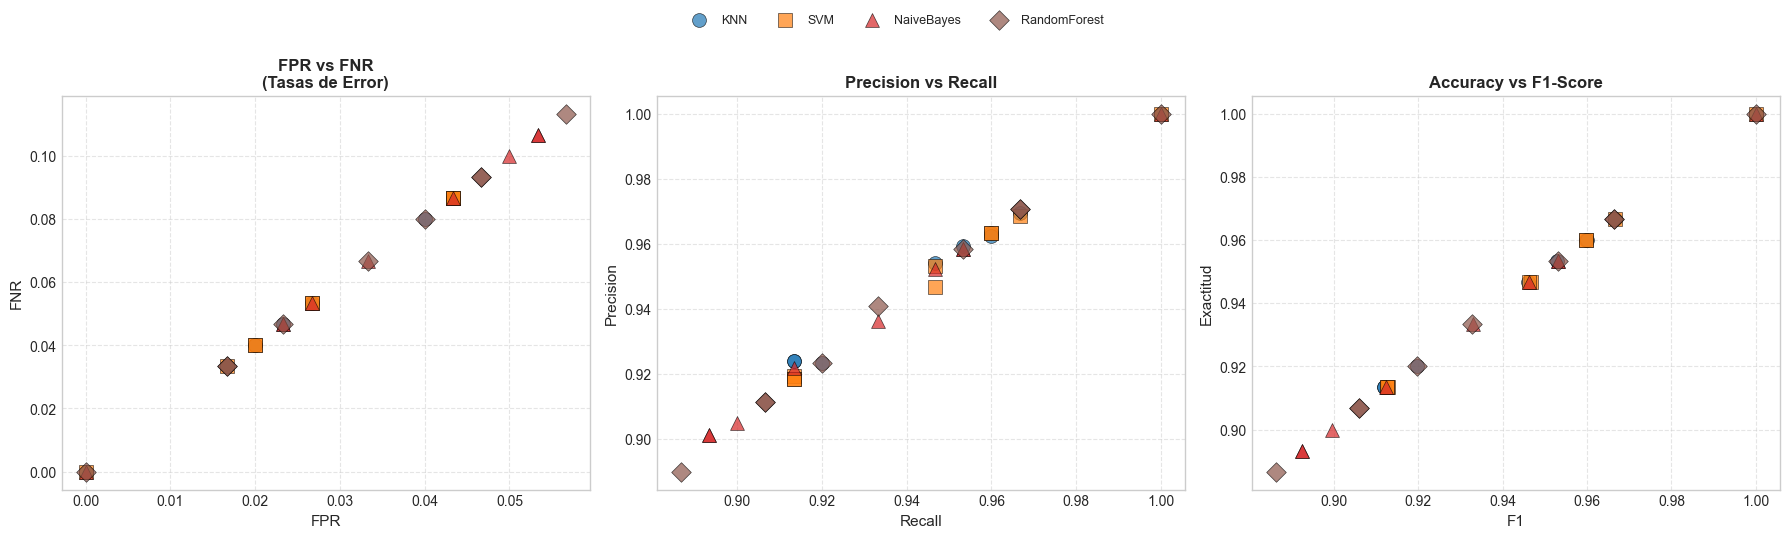


Gráfica guardada como 'comparacion_metricas.png'


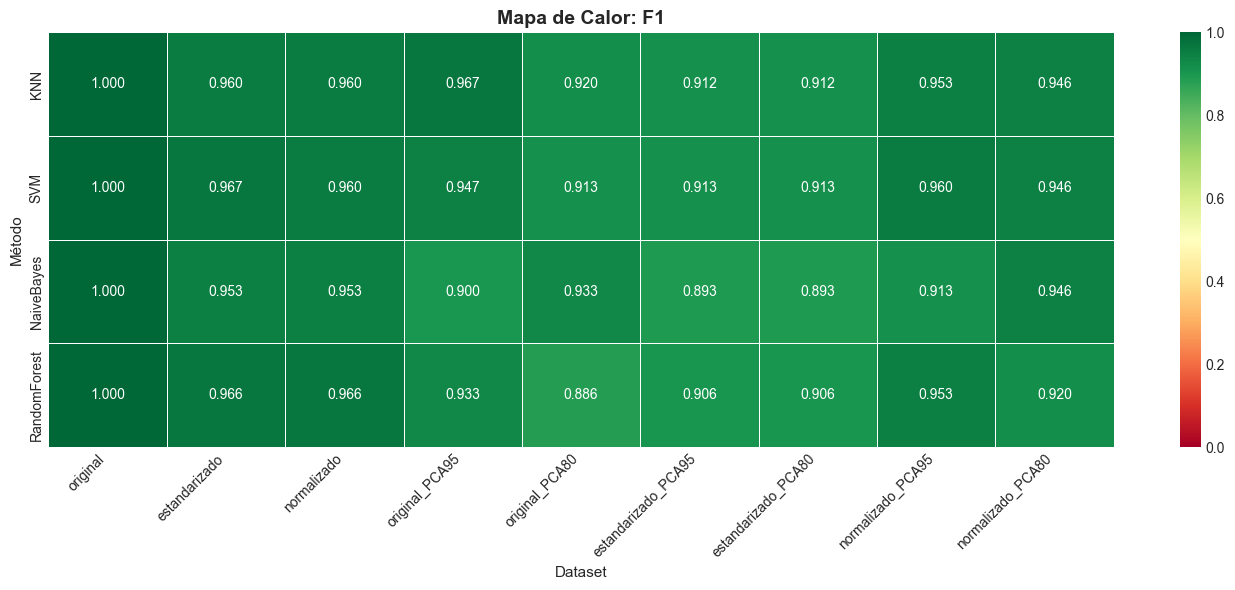


✓ Mapa de calor guardado como 'heatmap_F1.png'


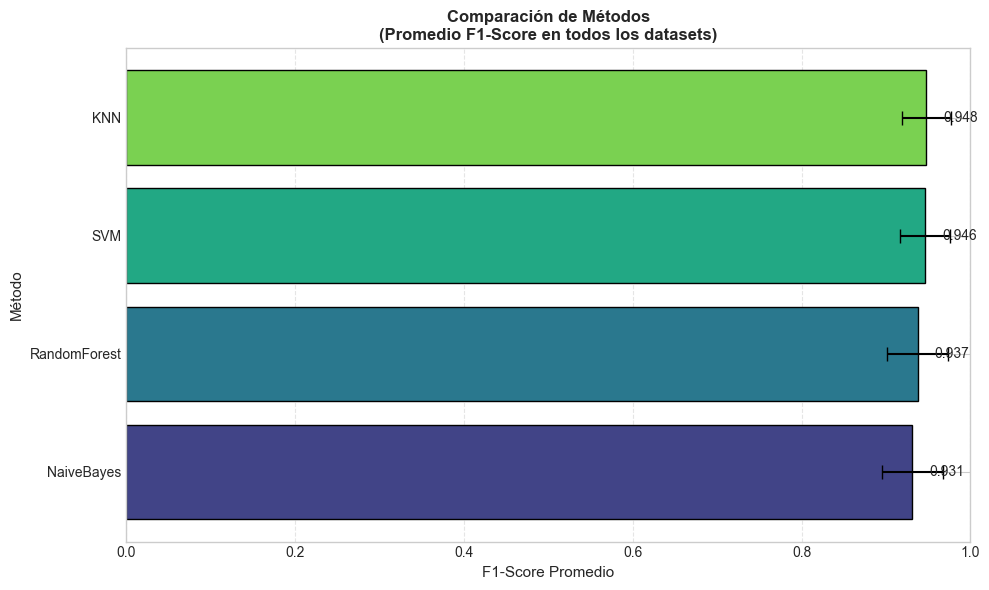


✓ Gráfica guardada como 'comparacion_metodos_barras.png'


In [11]:
def plot_comparisons(df):
    """
    Genera gráficas de dispersión comparando pares de métricas.
    
    Gráficas generadas:
    1. FPR vs FNR: Trade-off entre tipos de error
    2. Precision vs Recall: Balance precisión/cobertura
    3. Accuracy vs F1-Score: Comparación de métricas globales
    """
    # Verificar que hay datos
    if df.empty:
        print("No hay datos para graficar")
        return
    
    # Configuración de estilo
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Mapeo de colores por método
    colors = plt.cm.tab10(np.linspace(0, 1, len(METHODS)))
    method_color_map = dict(zip(METHODS, colors))
    
    # Marcadores diferentes para distinguir modelos base de ensembles
    markers = {'KNN': 'o', 'SVM': 's', 'NaiveBayes': '^', 'RandomForest': 'D',
               'Ensemble_Votacion': '*', 'Ensemble_Media': 'P', 'Ensemble_Mediana': 'X'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Pares de métricas a graficar (Eje X, Eje Y, Título)
    plot_pairs = [
        ('FPR_mean', 'FNR_mean', 'FPR vs FNR\n(Tasas de Error)'),
        ('Recall_mean', 'Precision_mean', 'Precision vs Recall'),
        ('F1_mean', 'Exactitud_mean', 'Accuracy vs F1-Score')
    ]
    
    for ax, (x_metric, y_metric, title) in zip(axes, plot_pairs):
        # Verificar que las columnas existen
        if x_metric not in df.columns or y_metric not in df.columns:
            ax.text(0.5, 0.5, f'Faltan columnas:\n{x_metric}\n{y_metric}', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
            
        for method in METHODS:
            subset = df[df['Method'] == method]
            if not subset.empty:
                marker = markers.get(method, 'o')
                ax.scatter(
                    subset[x_metric], 
                    subset[y_metric], 
                    label=method, 
                    color=method_color_map[method],
                    marker=marker,
                    s=100,
                    alpha=0.7,
                    edgecolors='black',
                    linewidth=0.5
                )
        
        ax.set_xlabel(x_metric.replace('_mean', ''), fontsize=11)
        ax.set_ylabel(y_metric.replace('_mean', ''), fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Leyenda única para toda la figura
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
               ncol=len(METHODS), fontsize=9)
    
    plt.tight_layout()
    plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nGráfica guardada como 'comparacion_metricas.png'")


def plot_metrics_heatmap(df, metric='F1_mean'):
    """
    Genera un mapa de calor para visualizar una métrica específica
    a través de todos los métodos y datasets.
    """
    if metric not in df.columns:
        print(f"Métrica '{metric}' no encontrada")
        return
    
    # Crear tabla pivote
    pivot = df.pivot(index='Method', columns='Dataset', values=metric)
    
    # Reordenar
    method_order = [m for m in METHODS if m in pivot.index]
    dataset_order = [d for d in DATASETS if d in pivot.columns]
    pivot = pivot.loc[method_order, dataset_order]
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
                linewidths=0.5, vmin=0, vmax=1)
    plt.title(f'Mapa de Calor: {metric.replace("_mean", "")}', fontsize=14, fontweight='bold')
    plt.xlabel('Dataset', fontsize=11)
    plt.ylabel('Método', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'heatmap_{metric.replace("_mean", "")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nMapa de calor guardado como 'heatmap_{metric.replace('_mean', '')}.png'")


def plot_method_comparison_bars(df):
    """
    Genera gráfico de barras comparando el rendimiento promedio
    de cada método a través de todos los datasets.
    """
    if df.empty:
        print("No hay datos para graficar")
        return
    
    # Calcular media de F1 por método
    method_avg = df.groupby('Method')['F1_mean'].mean().sort_values(ascending=True)
    method_std = df.groupby('Method')['F1_mean'].std()
    
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(method_avg)))
    bars = plt.barh(method_avg.index, method_avg.values, xerr=method_std[method_avg.index], 
                    color=colors, edgecolor='black', capsize=5)
    
    plt.xlabel('F1-Score Promedio', fontsize=11)
    plt.ylabel('Método', fontsize=11)
    plt.title('Comparación de Métodos\n(Promedio F1-Score en todos los datasets)', 
              fontsize=12, fontweight='bold')
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Añadir valores en las barras
    for bar, val in zip(bars, method_avg.values):
        plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('comparacion_metodos_barras.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nGráfica guardada como 'comparacion_metodos_barras.png'")


# Ejecutar todas las gráficas
print("Generando gráficas comparativas...\n")
plot_comparisons(df_results)
plot_metrics_heatmap(df_results, 'F1_mean')
plot_method_comparison_bars(df_results)